<a href="https://colab.research.google.com/github/z55vz/DL_Project/blob/main/DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Model Performance Comparison
----------------------------------
                 Model       AUC  Brier Score
0  Logistic Regression  0.945288     0.090528
1  Deep Neural Network  0.957334     0.083630

Revenue Optimization Results
----------------------------------
Average Base Revenue: 6.916
Average Optimized Revenue: 10.059
Revenue Improvement: 45.46%

Sample of Optimized Requests (First 10 Rows)
----------------------------------
        distance_km  is_peak  is_rainy     p_base  Optimal_Price  \
170977     3.444444        0         0  10.755556       8.450794   
85012      5.622222        0         0  12.497778      10.584853   
22192      5.188889        0         0  12.151111      10.043265   
104801     2.955556        1         0  10.364444       8.778050   
82643      7.388889        1         1  13.911111      12.349660   
33667      8.977778        0         0  15.182222      13.787937   
82945      8.733333        0         0  14.986667      13.610340   
142112     6.5222

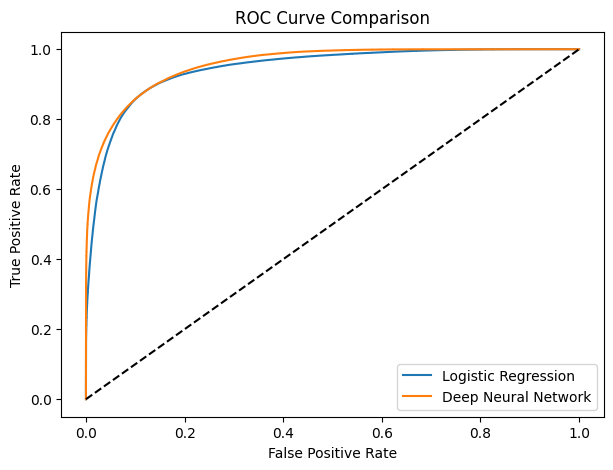

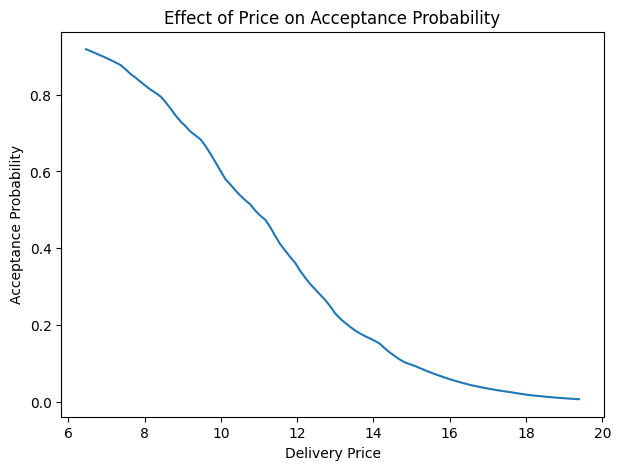

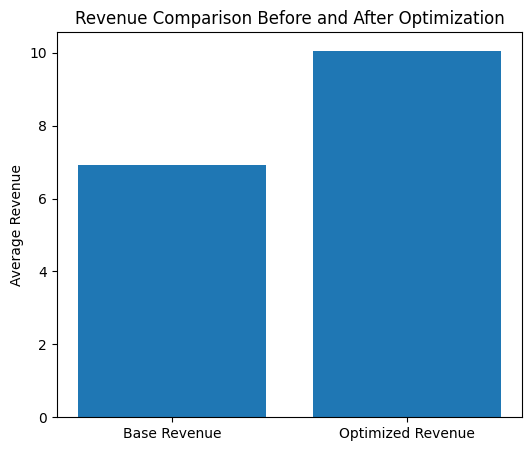

In [5]:
# PROJECT: AI-Based Dynamic Pricing for Delivery Services
# AUTHOR: Abdulrahman Jaber Ageeli
# UNIVERSITY: Umm Al-Qura University
# DESCRIPTION: This project applies machine learning and deep learning to estimate
# customer acceptance probability for delivery prices and optimize pricing in order
# to maximize expected revenue.

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the historical dataset and keep required columns
df = pd.read_csv("historical_data.csv")
df = df[["created_at", "estimated_store_to_consumer_driving_duration"]].dropna()

# Convert timestamp to datetime and create time-related features
df["created_at"] = pd.to_datetime(df["created_at"])
df["hour"] = df["created_at"].dt.hour

# Identify peak hours where demand is typically higher
df["is_peak"] = (
    ((df["hour"] >= 11) & (df["hour"] <= 14)) |
    ((df["hour"] >= 18) & (df["hour"] <= 21))
).astype(int)

# Estimate delivery distance using driving duration and assumed average speed
AVG_CITY_SPEED = 40
df["distance_km"] = (df["estimated_store_to_consumer_driving_duration"] / 3600) * AVG_CITY_SPEED
df = df[df["distance_km"] > 0].copy()

# Simulate weather conditions that may affect customer behavior
rain_probability = 0.2 + 0.1 * df["is_peak"]
df["is_rainy"] = (np.random.rand(len(df)) < rain_probability).astype(int)

# Define a base delivery price as a function of distance
df["p_base"] = 8 + 0.8 * df["distance_km"]

# Split dataset into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Simulate customer acceptance behavior for multiple price scenarios
def simulate_market(data, n_prices=10):

    data_rep = pd.concat([data] * n_prices, ignore_index=True)
    n = len(data_rep)

    alpha = (
        0.15
        + 0.05 * data_rep["distance_km"]
        + 0.02 * (data_rep["distance_km"] ** 2)
        + 0.08 * data_rep["distance_km"] * data_rep["is_rainy"]
        - 0.07 * data_rep["is_peak"]
    )

    delta = np.random.uniform(-0.5 * data_rep["p_base"], 0.5 * data_rep["p_base"], n)
    price = np.maximum(2.0, data_rep["p_base"] + delta)

    eps = np.random.normal(0, 0.5, n)

    z = -alpha * (price - data_rep["p_base"]) + eps
    p_accept = 1 / (1 + np.exp(-z))

    target = (np.random.rand(n) < p_accept).astype(int)

    return pd.DataFrame({
        "distance": data_rep["distance_km"],
        "is_peak": data_rep["is_peak"],
        "is_rainy": data_rep["is_rainy"],
        "price": price,
        "p_base": data_rep["p_base"],
        "target": target
    })

# Generate simulated market data for training and testing
train_sim = simulate_market(train_df)
test_sim = simulate_market(test_df)

# Prepare model input features
features = ["distance", "is_peak", "is_rainy", "price", "p_base"]

X_train = train_sim[features]
X_test = test_sim[features]

y_train = train_sim["target"]
y_test = test_sim["target"]

# Standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression as a baseline model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

lr_probs = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Build a Deep Neural Network model
dnn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the neural network
dnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

# Train the neural network
dnn.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=1024,
    verbose=0
)

# Predict probabilities using the trained neural network
dnn_probs = dnn.predict(X_test_scaled, batch_size=2048, verbose=0).ravel()

# Evaluate model performance
lr_auc = roc_auc_score(y_test, lr_probs)
dnn_auc = roc_auc_score(y_test, dnn_probs)

lr_brier = brier_score_loss(y_test, lr_probs)
dnn_brier = brier_score_loss(y_test, dnn_probs)

print("\nModel Performance Comparison")
print("----------------------------------")

performance_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Deep Neural Network"],
    "AUC": [lr_auc, dnn_auc],
    "Brier Score": [lr_brier, dnn_brier]
})

print(performance_table)

# Optimize delivery prices to maximize expected revenue
N = 500
sample = test_df.head(N).copy()

base_prices = sample["p_base"].values
price_grid = np.linspace(0.5, 1.5, 50)

best_revenue = np.zeros(N)
best_price = np.zeros(N)

# Evaluate different price factors
for factor in price_grid:

    candidate_prices = base_prices * factor

    X_opt = pd.DataFrame({
        "distance": sample["distance_km"],
        "is_peak": sample["is_peak"],
        "is_rainy": sample["is_rainy"],
        "price": candidate_prices,
        "p_base": base_prices
    })

    probs = dnn.predict(
        scaler.transform(X_opt),
        batch_size=2048,
        verbose=0
    ).ravel()

    revenue = candidate_prices * probs

    mask = revenue > best_revenue
    best_revenue[mask] = revenue[mask]
    best_price[mask] = candidate_prices[mask]

# Calculate baseline revenue using original price
X_base = pd.DataFrame({
    "distance": sample["distance_km"],
    "is_peak": sample["is_peak"],
    "is_rainy": sample["is_rainy"],
    "price": base_prices,
    "p_base": base_prices
})

base_probs = dnn.predict(
    scaler.transform(X_base),
    batch_size=2048,
    verbose=0
).ravel()

base_revenue = base_prices * base_probs

avg_base_revenue = np.mean(base_revenue)
avg_optimized_revenue = np.mean(best_revenue)

revenue_improvement = ((avg_optimized_revenue - avg_base_revenue) / avg_base_revenue) * 100

# Print revenue improvement
print("\nRevenue Optimization Results")
print("----------------------------------")
print(f"Average Base Revenue: {avg_base_revenue:.3f}")
print(f"Average Optimized Revenue: {avg_optimized_revenue:.3f}")
print(f"Revenue Improvement: {revenue_improvement:.2f}%")

# Store optimized results
sample["Optimal_Price"] = best_price
sample["Optimized_Revenue"] = best_revenue

# Display the most important columns for the first 10 rows
print("\nSample of Optimized Requests (First 10 Rows)")
print("----------------------------------")

print(
    sample[
        ["distance_km", "is_peak", "is_rainy", "p_base", "Optimal_Price", "Optimized_Revenue"]
    ].head(10)
)

# Generate ROC Curve to visually compare model performance
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, dnn_probs)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dnn, tpr_dnn, label="Deep Neural Network")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# Plot relationship between delivery price and acceptance probability
price_range = np.linspace(sample["p_base"].mean()*0.5, sample["p_base"].mean()*1.5, 100)

example_row = sample.iloc[0]

X_price_test = pd.DataFrame({
    "distance": [example_row["distance_km"]]*100,
    "is_peak": [example_row["is_peak"]]*100,
    "is_rainy": [example_row["is_rainy"]]*100,
    "price": price_range,
    "p_base": [example_row["p_base"]]*100
})

probs_price = dnn.predict(
    scaler.transform(X_price_test),
    batch_size=1024,
    verbose=0
).ravel()

plt.figure(figsize=(7,5))
plt.plot(price_range, probs_price)
plt.xlabel("Delivery Price")
plt.ylabel("Acceptance Probability")
plt.title("Effect of Price on Acceptance Probability")
plt.show()


# Compare average base revenue and optimized revenue
plt.figure(figsize=(6,5))
plt.bar(
    ["Base Revenue","Optimized Revenue"],
    [avg_base_revenue, avg_optimized_revenue]
)
plt.ylabel("Average Revenue")
plt.title("Revenue Comparison Before and After Optimization")
plt.show()